In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
archivo = "beyblade_pca_input.csv"

dataset = pd.read_csv(archivo)

print("Dimensiones:", dataset.shape)

display(dataset.head())

Dimensiones: (407, 41)


,source,product_name,product_type,brand,price,currency,stock_status,blade_count,ratchet_count,bit_count,...,package_first_rate_max,package_win_share_mean,package_win_share_max,package_match_coverage,package_meta_coverage,in_stock,scenario_id,ingreso_personal_mensual_mxn,price_income_pct,price_per_bey
0,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,...,42.9,5.166667,45.5,1.0,1.0,0,LOW_01,4001,129.942514,1299.75
1,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,...,42.9,5.166667,45.5,1.0,1.0,0,LOW_02,4500,115.533333,1299.75
2,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,...,42.9,5.166667,45.5,1.0,1.0,0,LOW_03,5000,103.980000,1299.75
3,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,...,42.9,5.166667,45.5,1.0,1.0,0,LOW_04,5500,94.527273,1299.75
4,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,...,42.9,5.166667,45.5,1.0,1.0,0,LOW_05,6000,86.650000,1299.75


In [3]:
with open(
    "pca_candidate_features.json",
    "r",
    encoding="utf-8"
) as archivo:
    features_candidatas = json.load(archivo)

print(features_candidatas)

['price', 'bey_count', 'blade_count', 'ratchet_count', 'bit_count', 'launcher_count', 'stadium_count', 'launcher_included', 'stadium_included', 'in_stock', 'package_usage_mean', 'package_usage_max', 'package_top_cuts_mean', 'package_top_cuts_max', 'package_first_rate_mean', 'package_first_rate_max', 'package_win_share_mean', 'package_win_share_max', 'package_match_coverage', 'package_meta_coverage', 'ingreso_personal_mensual_mxn', 'price_income_pct', 'price_per_bey']


In [4]:
features_disponibles = [
    columna
    for columna in features_candidatas
    if columna in dataset.columns
]

features_faltantes = [
    columna
    for columna in features_candidatas
    if columna not in dataset.columns
]

print(
    "Features disponibles:",
    len(features_disponibles)
)

print(
    "Features faltantes:",
    features_faltantes
)

Features disponibles: 23
Features faltantes: []


In [5]:
features_pca = [
    # Economía
    "price",
    "price_income_pct",
    "price_per_bey",

    # Contenido
    "bey_count",
    "launcher_included",
    "stadium_included",

    # Valor competitivo
    "package_usage_mean",
    "package_usage_max",
    "package_top_cuts_mean",
    "package_top_cuts_max",

    # Calidad / cobertura de datos
    "package_meta_coverage"
]

In [6]:
features_pca = [
    columna
    for columna in features_pca
    if columna in dataset.columns
]

print(features_pca)

['price', 'price_income_pct', 'price_per_bey', 'bey_count', 'launcher_included', 'stadium_included', 'package_usage_mean', 'package_usage_max', 'package_top_cuts_mean', 'package_top_cuts_max', 'package_meta_coverage']


In [7]:
X = dataset[
    features_pca
].copy()

display(X.head())

print("Shape de X:", X.shape)

,price,price_income_pct,price_per_bey,bey_count,launcher_included,stadium_included,package_usage_mean,package_usage_max,package_top_cuts_mean,package_top_cuts_max,package_meta_coverage
0,5199.0,129.942514,1299.75,4,1,0,5.55,46.5,536.083333,4488.0,1.0
1,5199.0,115.533333,1299.75,4,1,0,5.55,46.5,536.083333,4488.0,1.0
2,5199.0,103.980000,1299.75,4,1,0,5.55,46.5,536.083333,4488.0,1.0
3,5199.0,94.527273,1299.75,4,1,0,5.55,46.5,536.083333,4488.0,1.0
4,5199.0,86.650000,1299.75,4,1,0,5.55,46.5,536.083333,4488.0,1.0


Shape de X: (407, 11)


In [8]:
print(
    X.isnull().sum()
)

price                    0
price_income_pct         0
price_per_bey            0
bey_count                0
launcher_included        0
stadium_included         0
package_usage_mean       0
package_usage_max        0
package_top_cuts_mean    0
package_top_cuts_max     0
package_meta_coverage    0
dtype: int64


In [9]:
print(
    np.isinf(
        X.select_dtypes(
            include=np.number
        )
    ).sum()
)

price                    0
price_income_pct         0
price_per_bey            0
bey_count                0
launcher_included        0
stadium_included         0
package_usage_mean       0
package_usage_max        0
package_top_cuts_mean    0
package_top_cuts_max     0
package_meta_coverage    0
dtype: int64


In [10]:
display(
    X.describe().T
)

,count,mean,std,min,25%,50%,75%,max
price,407.0,1849.270270,1523.056842,599.000000,799.000000,1259.000000,1999.000000,6599.000000
price_income_pct,407.0,30.335627,27.028973,6.656295,12.096234,19.988235,36.832727,164.933767
price_per_bey,407.0,1715.074324,1432.154462,533.000000,799.000000,1099.000000,1999.000000,6599.000000
bey_count,407.0,1.135135,0.577850,1.000000,1.000000,1.000000,1.000000,4.000000
launcher_included,407.0,0.378378,0.485580,0.000000,0.000000,0.000000,1.000000,1.000000
stadium_included,407.0,0.027027,0.162362,0.000000,0.000000,0.000000,0.000000,1.000000
package_usage_mean,407.0,8.790691,9.798038,0.200000,1.933333,4.333333,12.966667,39.350000
package_usage_max,407.0,21.994595,23.015420,0.200000,2.900000,17.700000,29.100000,75.500000
package_top_cuts_mean,407.0,848.765015,946.562284,19.666667,186.333333,417.333333,1252.666667,3801.000000
package_top_cuts_max,407.0,2124.540541,2221.312136,23.000000,279.000000,1713.000000,2815.000000,7289.000000


In [11]:
print(
    "Filas duplicadas exactas en X:",
    X.duplicated().sum()
)

Filas duplicadas exactas en X: 0


In [12]:
filas_con_nulos = dataset[
    X.isnull().any(axis=1)
]

print(
    "Filas con al menos un NaN:",
    len(filas_con_nulos)
)

display(
    filas_con_nulos[
        [
            "product_name"
        ]
        + features_pca
    ].head(30)
)

Filas con al menos un NaN: 0


,product_name,price,price_income_pct,price_per_bey,bey_count,launcher_included,stadium_included,package_usage_mean,package_usage_max,package_top_cuts_mean,package_top_cuts_max,package_meta_coverage


In [13]:
print("Dimensiones:", dataset.shape)

print(X.isnull().sum())

display(X.describe().T)

Dimensiones: (407, 41)
price                    0
price_income_pct         0
price_per_bey            0
bey_count                0
launcher_included        0
stadium_included         0
package_usage_mean       0
package_usage_max        0
package_top_cuts_mean    0
package_top_cuts_max     0
package_meta_coverage    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
price,407.0,1849.270270,1523.056842,599.000000,799.000000,1259.000000,1999.000000,6599.000000
price_income_pct,407.0,30.335627,27.028973,6.656295,12.096234,19.988235,36.832727,164.933767
price_per_bey,407.0,1715.074324,1432.154462,533.000000,799.000000,1099.000000,1999.000000,6599.000000
bey_count,407.0,1.135135,0.577850,1.000000,1.000000,1.000000,1.000000,4.000000
launcher_included,407.0,0.378378,0.485580,0.000000,0.000000,0.000000,1.000000,1.000000
stadium_included,407.0,0.027027,0.162362,0.000000,0.000000,0.000000,0.000000,1.000000
package_usage_mean,407.0,8.790691,9.798038,0.200000,1.933333,4.333333,12.966667,39.350000
package_usage_max,407.0,21.994595,23.015420,0.200000,2.900000,17.700000,29.100000,75.500000
package_top_cuts_mean,407.0,848.765015,946.562284,19.666667,186.333333,417.333333,1252.666667,3801.000000
package_top_cuts_max,407.0,2124.540541,2221.312136,23.000000,279.000000,1713.000000,2815.000000,7289.000000


In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
print(
    "Media aproximada:",
    X_scaled.mean(axis=0)
)

print(
    "\nDesviación aproximada:",
    X_scaled.std(axis=0)
)

Media aproximada: [ 5.23741574e-17  6.54676968e-17 -1.13477341e-16  1.22206367e-16
  6.98322099e-17  3.49161050e-17 -1.39664420e-16  1.92038577e-16
 -5.23741574e-17  8.72902624e-17 -3.92806181e-16]

Desviación aproximada: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [16]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [17]:
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [18]:
varianza_explicada = (
    pca.explained_variance_ratio_
)

varianza_acumulada = np.cumsum(
    varianza_explicada
)

tabla_varianza = pd.DataFrame({
    "Componente": [
        f"PC{i+1}"
        for i in range(
            len(varianza_explicada)
        )
    ],

    "Varianza_explicada":
        varianza_explicada,

    "Varianza_acumulada":
        varianza_acumulada
})

display(tabla_varianza)

,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,3.967398e-01,0.396740
1,PC2,2.362026e-01,0.632942
2,PC3,1.122965e-01,0.745239
3,PC4,1.006719e-01,0.845911
4,PC5,8.216694e-02,0.928078
5,PC6,5.767213e-02,0.985750
6,PC7,9.216587e-03,0.994966
7,PC8,4.365778e-03,0.999332
8,PC9,6.677272e-04,1.000000
9,PC10,4.937507e-08,1.000000


In [19]:
tabla_varianza["Varianza_explicada_pct"] = (
    tabla_varianza["Varianza_explicada"]
    * 100
)

tabla_varianza["Varianza_acumulada_pct"] = (
    tabla_varianza["Varianza_acumulada"]
    * 100
)

display(
    tabla_varianza[
        [
            "Componente",
            "Varianza_explicada_pct",
            "Varianza_acumulada_pct"
        ]
    ]
)

,Componente,Varianza_explicada_pct,Varianza_acumulada_pct
0,PC1,39.673975,39.673975
1,PC2,23.620264,63.294240
2,PC3,11.229647,74.523887
3,PC4,10.067189,84.591076
4,PC5,8.216694,92.807770
5,PC6,5.767213,98.574983
6,PC7,0.921659,99.496642
7,PC8,0.436578,99.933220
8,PC9,0.066773,99.999992
9,PC10,0.000005,99.999997


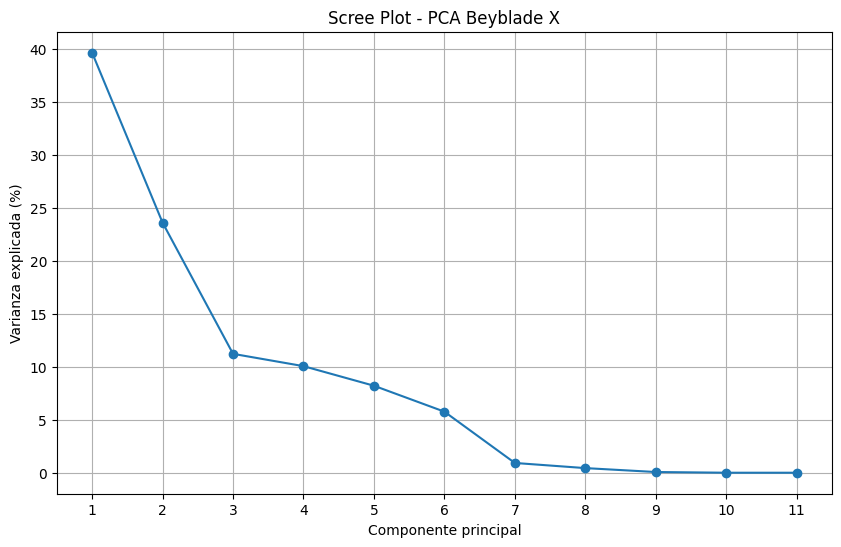

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(
        1,
        len(varianza_explicada) + 1
    ),
    varianza_explicada * 100,
    marker="o"
)

plt.xlabel(
    "Componente principal"
)

plt.ylabel(
    "Varianza explicada (%)"
)

plt.title(
    "Scree Plot - PCA Beyblade X"
)

plt.xticks(
    range(
        1,
        len(varianza_explicada) + 1
    )
)

plt.grid()

plt.show()

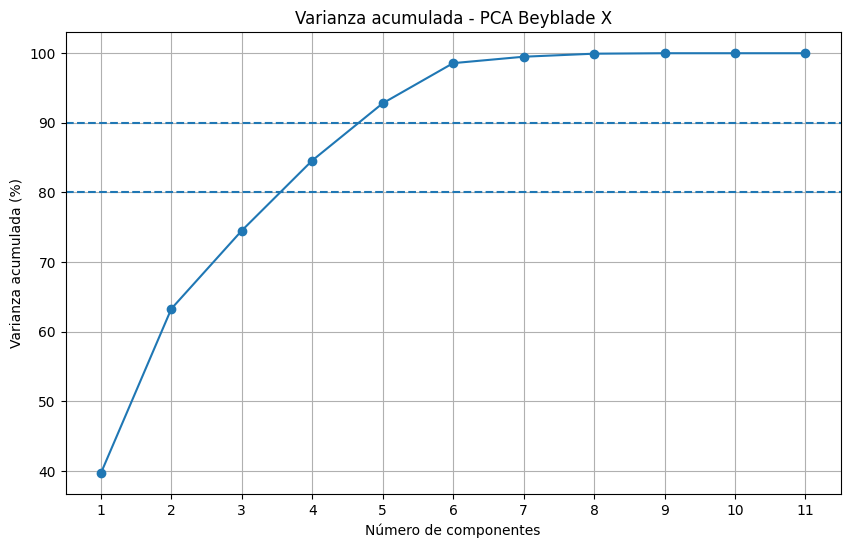

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(
        1,
        len(varianza_acumulada) + 1
    ),
    varianza_acumulada * 100,
    marker="o"
)

plt.axhline(
    y=80,
    linestyle="--"
)

plt.axhline(
    y=90,
    linestyle="--"
)

plt.xlabel(
    "Número de componentes"
)

plt.ylabel(
    "Varianza acumulada (%)"
)

plt.title(
    "Varianza acumulada - PCA Beyblade X"
)

plt.xticks(
    range(
        1,
        len(varianza_acumulada) + 1
    )
)

plt.grid()

plt.show()

In [22]:
componentes_80 = (
    np.argmax(
        varianza_acumulada >= 0.80
    )
    + 1
)

componentes_90 = (
    np.argmax(
        varianza_acumulada >= 0.90
    )
    + 1
)

componentes_95 = (
    np.argmax(
        varianza_acumulada >= 0.95
    )
    + 1
)

print(
    "Componentes para 80%:",
    componentes_80
)

print(
    "Componentes para 90%:",
    componentes_90
)

print(
    "Componentes para 95%:",
    componentes_95
)

Componentes para 80%: 4
Componentes para 90%: 5
Componentes para 95%: 6


In [23]:
nombres_componentes = [
    f"PC{i+1}"
    for i in range(len(features_pca))
]

loadings = pd.DataFrame(
    pca.components_.T,
    index=features_pca,
    columns=nombres_componentes
)

display(
    loadings.iloc[:, :5].round(3)
)

,PC1,PC2,PC3,PC4,PC5
price,0.223,0.539,-0.023,0.075,0.023
price_income_pct,0.214,0.528,-0.024,0.080,0.026
price_per_bey,0.207,0.499,-0.279,-0.189,-0.089
bey_count,0.046,0.148,0.571,0.629,0.263
launcher_included,0.220,-0.068,0.500,-0.244,0.017
stadium_included,0.119,0.023,0.167,-0.575,0.719
package_usage_mean,0.440,-0.204,-0.146,0.007,-0.085
package_usage_max,0.453,-0.167,0.047,0.101,-0.024
package_top_cuts_mean,0.440,-0.204,-0.146,0.007,-0.084
package_top_cuts_max,0.453,-0.167,0.047,0.101,-0.024


In [24]:
for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:

    print("\n", "=" * 60)
    print(pc)
    print("=" * 60)

    importancia = (
        loadings[pc]
        .sort_values(
            key=lambda x: x.abs(),
            ascending=False
        )
    )

    display(
        importancia.to_frame(
            name="loading"
        )
    )


PC1


,loading
package_top_cuts_max,0.452676
package_usage_max,0.452671
package_top_cuts_mean,0.439926
package_usage_mean,0.439895
price,0.223318
launcher_included,0.219735
price_income_pct,0.213548
price_per_bey,0.207409
stadium_included,0.119293
bey_count,0.045935



PC2


,loading
price,0.539180
price_income_pct,0.527974
price_per_bey,0.498692
package_usage_mean,-0.204446
package_top_cuts_mean,-0.204312
package_usage_max,-0.166801
package_top_cuts_max,-0.166750
bey_count,0.147658
package_meta_coverage,0.125568
launcher_included,-0.067540



PC3


,loading
bey_count,0.571106
package_meta_coverage,0.520183
launcher_included,0.499535
price_per_bey,-0.278717
stadium_included,0.166633
package_top_cuts_mean,-0.146379
package_usage_mean,-0.145993
package_usage_max,0.047242
package_top_cuts_max,0.047005
price_income_pct,-0.023781



PC4


,loading
bey_count,0.629392
stadium_included,-0.575061
package_meta_coverage,-0.381015
launcher_included,-0.244325
price_per_bey,-0.189497
package_top_cuts_max,0.100778
package_usage_max,0.100591
price_income_pct,0.079892
price,0.075069
package_top_cuts_mean,0.007227



PC5


,loading
stadium_included,0.718994
package_meta_coverage,-0.623848
bey_count,0.262549
price_per_bey,-0.089320
package_usage_mean,-0.084837
package_top_cuts_mean,-0.084332
price_income_pct,0.025679
package_top_cuts_max,-0.023963
package_usage_max,-0.023949
price,0.023306


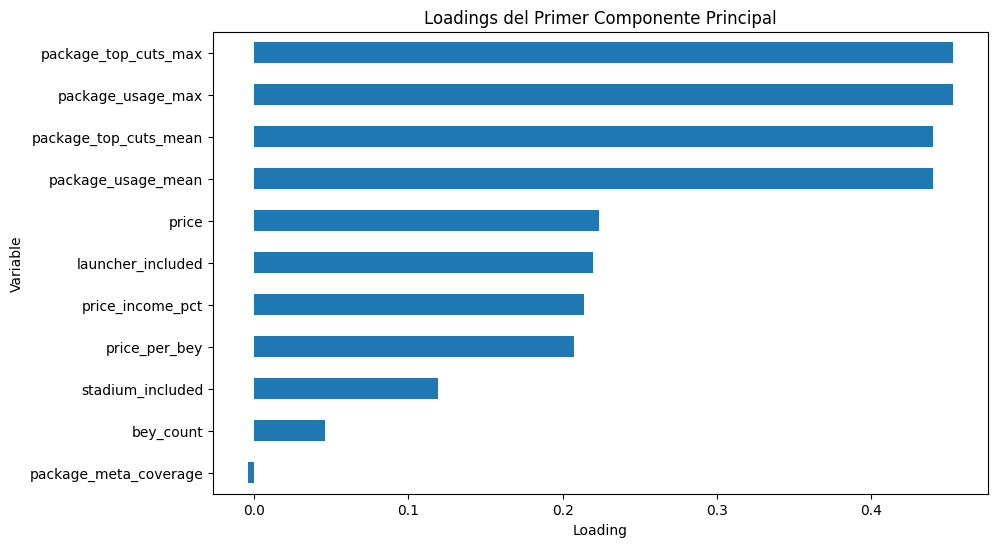

In [25]:
loadings["PC1"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title(
    "Loadings del Primer Componente Principal"
)

plt.xlabel(
    "Loading"
)

plt.ylabel(
    "Variable"
)

plt.show()

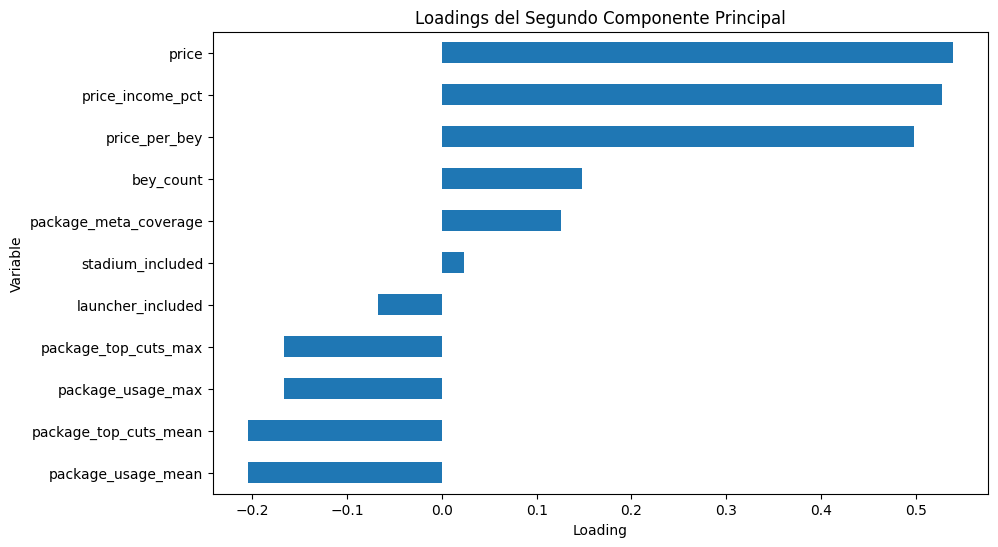

In [26]:
loadings["PC2"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title(
    "Loadings del Segundo Componente Principal"
)

plt.xlabel(
    "Loading"
)

plt.ylabel(
    "Variable"
)

plt.show()

In [27]:
pca_final = PCA(
    n_components=5
)

X_pca_final = pca_final.fit_transform(
    X_scaled
)

In [28]:
df_componentes = pd.DataFrame(
    X_pca_final,
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5"
    ],
    index=dataset.index
)

display(
    df_componentes.head()
)

,PC1,PC2,PC3,PC4,PC5
0,2.382021,3.441352,3.705447,3.545757,1.241199
1,2.268038,3.159542,3.718141,3.503113,1.227493
2,2.176646,2.933586,3.728318,3.468922,1.216503
3,2.101871,2.748712,3.736646,3.440947,1.207511
4,2.039558,2.594651,3.743585,3.417635,1.200018


In [29]:
df_resultado_pca = pd.concat(
    [
        dataset[
            [
                "product_name",
                "scenario_id",
                "ingreso_personal_mensual_mxn",
                "price",
                "price_income_pct"
            ]
        ].reset_index(drop=True),

        df_componentes.reset_index(drop=True)
    ],
    axis=1
)

display(
    df_resultado_pca.head(20)
)

,product_name,scenario_id,ingreso_personal_mensual_mxn,price,price_income_pct,PC1,PC2,PC3,PC4,PC5
0,BX-00 Beyblade 25th Anniversary Set,LOW_01,4001,5199.0,129.942514,2.382021,3.441352,3.705447,3.545757,1.241199
1,BX-00 Beyblade 25th Anniversary Set,LOW_02,4500,5199.0,115.533333,2.268038,3.159542,3.718141,3.503113,1.227493
2,BX-00 Beyblade 25th Anniversary Set,LOW_03,5000,5199.0,103.980000,2.176646,2.933586,3.728318,3.468922,1.216503
3,BX-00 Beyblade 25th Anniversary Set,LOW_04,5500,5199.0,94.527273,2.101871,2.748712,3.736646,3.440947,1.207511
4,BX-00 Beyblade 25th Anniversary Set,LOW_05,6000,5199.0,86.650000,2.039558,2.594651,3.743585,3.417635,1.200018
5,BX-00 Beyblade 25th Anniversary Set,LOW_06,6500,5199.0,79.984615,1.986832,2.464291,3.749457,3.397909,1.193678
6,BX-00 Beyblade 25th Anniversary Set,LOW_07,7000,5199.0,74.271429,1.941638,2.352555,3.754490,3.381001,1.188243
7,BX-00 Beyblade 25th Anniversary Set,LOW_08,7500,5199.0,69.320000,1.902470,2.255716,3.758851,3.366348,1.183533
8,BX-00 Beyblade 25th Anniversary Set,LOW_09,8000,5199.0,64.987500,1.868199,2.170982,3.762668,3.353526,1.179412
9,BX-00 Beyblade 25th Anniversary Set,LOW_10,8500,5199.0,61.164706,1.837959,2.096217,3.766036,3.342213,1.175776


In [30]:
display(loadings.iloc[:, :5].round(3))

,PC1,PC2,PC3,PC4,PC5
price,0.223,0.539,-0.023,0.075,0.023
price_income_pct,0.214,0.528,-0.024,0.080,0.026
price_per_bey,0.207,0.499,-0.279,-0.189,-0.089
bey_count,0.046,0.148,0.571,0.629,0.263
launcher_included,0.220,-0.068,0.500,-0.244,0.017
stadium_included,0.119,0.023,0.167,-0.575,0.719
package_usage_mean,0.440,-0.204,-0.146,0.007,-0.085
package_usage_max,0.453,-0.167,0.047,0.101,-0.024
package_top_cuts_mean,0.440,-0.204,-0.146,0.007,-0.084
package_top_cuts_max,0.453,-0.167,0.047,0.101,-0.024


In [31]:
correlaciones = X.corr()

display(
    correlaciones.round(3)
)

,price,price_income_pct,price_per_bey,bey_count,launcher_included,stadium_included,package_usage_mean,package_usage_max,package_top_cuts_mean,package_top_cuts_max,package_meta_coverage
price,1.000,0.924,0.905,0.294,0.102,0.104,0.142,0.213,0.142,0.213,0.104
price_income_pct,0.924,1.000,0.836,0.272,0.095,0.096,0.131,0.197,0.132,0.197,0.096
price_per_bey,0.905,0.836,1.000,-0.118,0.030,0.126,0.186,0.152,0.186,0.152,0.089
bey_count,0.294,0.272,-0.118,1.000,0.107,-0.039,-0.094,0.132,-0.094,0.132,0.053
launcher_included,0.102,0.095,0.030,0.107,1.000,0.214,0.330,0.409,0.330,0.408,0.176
stadium_included,0.104,0.096,0.126,-0.039,0.214,1.000,0.143,0.178,0.143,0.178,0.038
package_usage_mean,0.142,0.131,0.186,-0.094,0.330,0.143,1.000,0.945,1.000,0.945,-0.103
package_usage_max,0.213,0.197,0.152,0.132,0.409,0.178,0.945,1.000,0.945,1.000,-0.033
package_top_cuts_mean,0.142,0.132,0.186,-0.094,0.330,0.143,1.000,0.945,1.000,0.945,-0.104
package_top_cuts_max,0.213,0.197,0.152,0.132,0.408,0.178,0.945,1.000,0.945,1.000,-0.033


In [32]:
pares_correlacionados = []

for i in range(len(correlaciones.columns)):

    for j in range(i + 1, len(correlaciones.columns)):

        correlacion = correlaciones.iloc[i, j]

        if abs(correlacion) >= 0.90:

            pares_correlacionados.append({
                "variable_1":
                    correlaciones.columns[i],

                "variable_2":
                    correlaciones.columns[j],

                "correlacion":
                    correlacion
            })

df_correlaciones_altas = pd.DataFrame(
    pares_correlacionados
)

display(df_correlaciones_altas)

,variable_1,variable_2,correlacion
0,price,price_income_pct,0.924356
1,price,price_per_bey,0.904549
2,package_usage_mean,package_usage_max,0.945438
3,package_usage_mean,package_top_cuts_mean,0.999999
4,package_usage_mean,package_top_cuts_max,0.945483
5,package_usage_max,package_top_cuts_mean,0.945423
6,package_usage_max,package_top_cuts_max,0.999999
7,package_top_cuts_mean,package_top_cuts_max,0.945468


In [33]:
df_resultado_pca = pd.concat(
    [
        dataset[
            [
                "product_name",
                "product_type",
                "scenario_id",
                "ingreso_personal_mensual_mxn",
                "price",
                "price_income_pct"
            ]
        ].reset_index(drop=True),

        df_componentes.reset_index(drop=True)
    ],
    axis=1
)

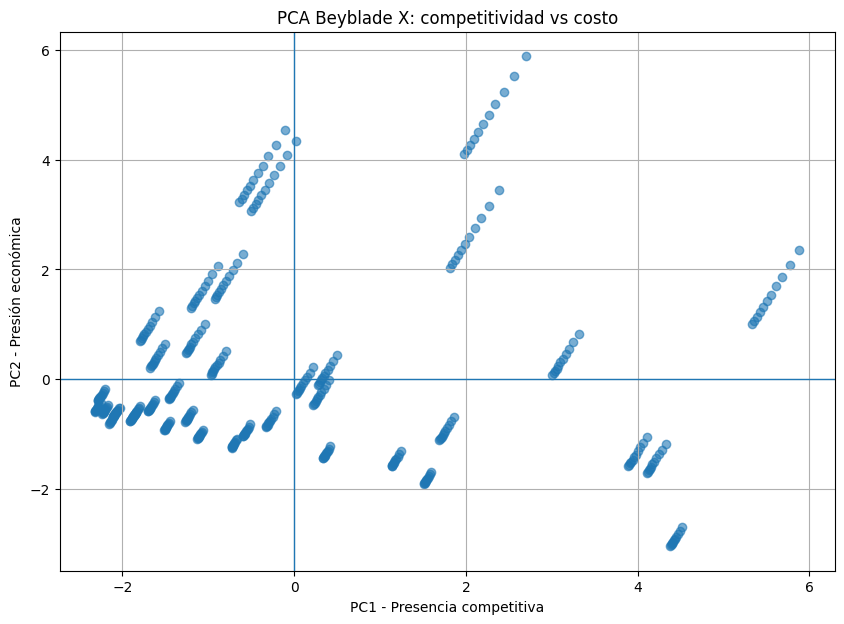

In [34]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df_resultado_pca["PC1"],
    df_resultado_pca["PC2"],
    alpha=0.6
)

plt.axhline(
    0,
    linewidth=1
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "PC1 - Presencia competitiva"
)

plt.ylabel(
    "PC2 - Presión económica"
)

plt.title(
    "PCA Beyblade X: competitividad vs costo"
)

plt.grid()

plt.show()

In [35]:
features_pca_final = [

    # Presión económica
    "price_income_pct",

    # Valor económico por contenido
    "price_per_bey",

    # Contenido físico
    "bey_count",
    "launcher_included",
    "stadium_included",

    # Valor competitivo
    "package_usage_mean",
    "package_usage_max",

    # Calidad de información competitiva
    "package_meta_coverage"
]

In [36]:
X_final = dataset[
    features_pca_final
].copy()

print("Dimensiones:", X_final.shape)

print("\nValores nulos:")
print(X_final.isnull().sum())

Dimensiones: (407, 8)

Valores nulos:
price_income_pct         0
price_per_bey            0
bey_count                0
launcher_included        0
stadium_included         0
package_usage_mean       0
package_usage_max        0
package_meta_coverage    0
dtype: int64


In [37]:
scaler_final = StandardScaler()

X_final_scaled = scaler_final.fit_transform(
    X_final
)

In [38]:
print(
    "Media:",
    X_final_scaled.mean(axis=0)
)

print(
    "\nDesviación:",
    X_final_scaled.std(axis=0)
)

Media: [ 6.54676968e-17 -1.13477341e-16  1.22206367e-16  6.98322099e-17
  3.49161050e-17 -1.39664420e-16  1.92038577e-16 -3.92806181e-16]

Desviación: [1. 1. 1. 1. 1. 1. 1. 1.]


In [39]:
pca_exploratorio_final = PCA()

X_pca_exploratorio = (
    pca_exploratorio_final.fit_transform(
        X_final_scaled
    )
)

In [40]:
varianza_final = (
    pca_exploratorio_final
    .explained_variance_ratio_
)

varianza_final_acumulada = np.cumsum(
    varianza_final
)

In [41]:
tabla_varianza_final = pd.DataFrame({
    "Componente": [
        f"PC{i+1}"
        for i in range(len(varianza_final))
    ],

    "Varianza_explicada_pct":
        varianza_final * 100,

    "Varianza_acumulada_pct":
        varianza_final_acumulada * 100
})

display(
    tabla_varianza_final.round(3)
)

,Componente,Varianza_explicada_pct,Varianza_acumulada_pct
0,PC1,30.930,30.930
1,PC2,20.696,51.626
2,PC3,14.953,66.579
3,PC4,13.433,80.012
4,PC5,11.088,91.100
5,PC6,7.596,98.696
6,PC7,1.000,99.696
7,PC8,0.304,100.000


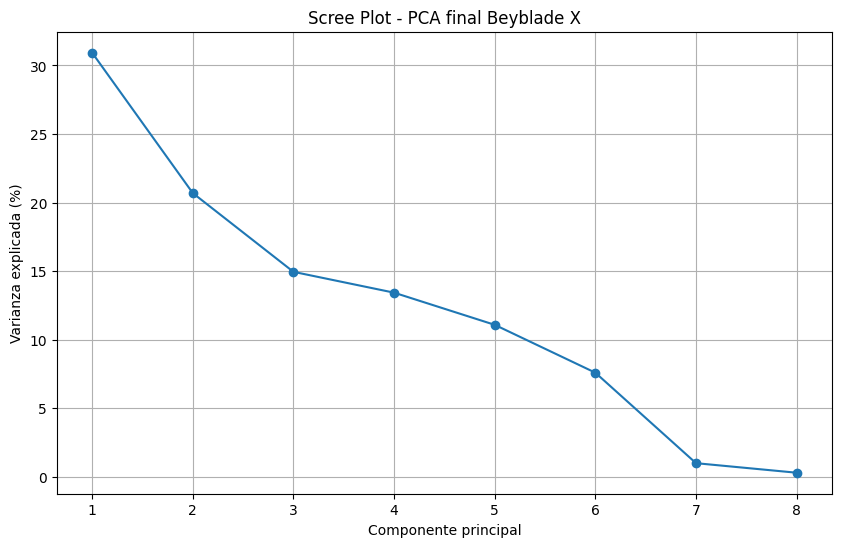

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(varianza_final) + 1),
    varianza_final * 100,
    marker="o"
)

plt.xlabel(
    "Componente principal"
)

plt.ylabel(
    "Varianza explicada (%)"
)

plt.title(
    "Scree Plot - PCA final Beyblade X"
)

plt.xticks(
    range(1, len(varianza_final) + 1)
)

plt.grid()

plt.show()

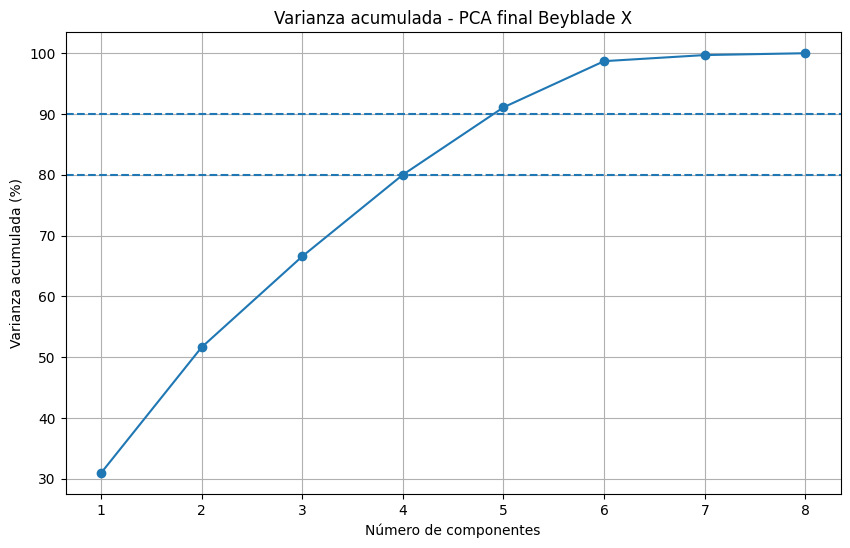

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(varianza_final_acumulada) + 1),
    varianza_final_acumulada * 100,
    marker="o"
)

plt.axhline(
    80,
    linestyle="--"
)

plt.axhline(
    90,
    linestyle="--"
)

plt.xlabel(
    "Número de componentes"
)

plt.ylabel(
    "Varianza acumulada (%)"
)

plt.title(
    "Varianza acumulada - PCA final Beyblade X"
)

plt.grid()

plt.show()

In [44]:
for limite in [0.80, 0.90, 0.95]:

    componentes = (
        np.argmax(
            varianza_final_acumulada >= limite
        )
        + 1
    )

    print(
        f"{int(limite * 100)}% ->",
        componentes,
        "componentes"
    )

80% -> 4 componentes
90% -> 5 componentes
95% -> 6 componentes


In [45]:
pca_final = PCA(
    n_components=5
)

X_pca_final = pca_final.fit_transform(
    X_final_scaled
)

In [46]:
df_componentes_final = pd.DataFrame(
    X_pca_final,
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5"
    ],
    index=dataset.index
)

display(
    df_componentes_final.head()
)

,PC1,PC2,PC3,PC4,PC5
0,2.475254,2.108708,3.780164,3.587212,1.380218
1,2.275888,1.792264,3.785465,3.499434,1.351609
2,2.116036,1.538539,3.789715,3.429052,1.328670
3,1.985247,1.330945,3.793192,3.371467,1.309902
4,1.876257,1.157950,3.796090,3.323480,1.294263


In [47]:
loadings_final = pd.DataFrame(
    pca_final.components_.T,
    index=features_pca_final,
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5"
    ]
)

display(
    loadings_final.round(3)
)

,PC1,PC2,PC3,PC4,PC5
price_income_pct,0.374,0.593,-0.010,0.164,0.054
price_per_bey,0.355,0.569,-0.279,-0.104,-0.076
bey_count,0.077,0.110,0.611,0.620,0.301
launcher_included,0.340,-0.214,0.428,-0.213,-0.028
stadium_included,0.219,-0.035,0.076,-0.542,0.760
package_usage_mean,0.516,-0.353,-0.225,0.088,-0.178
package_usage_max,0.544,-0.328,-0.030,0.174,-0.104
package_meta_coverage,0.047,0.185,0.556,-0.448,-0.529


In [48]:
for pc in [
    "PC1",
    "PC2",
    "PC3",
    "PC4",
    "PC5"
]:

    print("\n" + "=" * 60)
    print(pc)
    print("=" * 60)

    importancia = (
        loadings_final[pc]
        .sort_values(
            key=lambda x: x.abs(),
            ascending=False
        )
    )

    display(
        importancia.to_frame(
            name="loading"
        )
    )


PC1


,loading
package_usage_max,0.544049
package_usage_mean,0.516146
price_income_pct,0.373514
price_per_bey,0.355329
launcher_included,0.340439
stadium_included,0.218788
bey_count,0.076704
package_meta_coverage,0.046713



PC2


,loading
price_income_pct,0.592860
price_per_bey,0.568878
package_usage_mean,-0.352561
package_usage_max,-0.327934
launcher_included,-0.213569
package_meta_coverage,0.184875
bey_count,0.109876
stadium_included,-0.034516



PC3


,loading
bey_count,0.610714
package_meta_coverage,0.555568
launcher_included,0.427844
price_per_bey,-0.279315
package_usage_mean,-0.224792
stadium_included,0.076131
package_usage_max,-0.029637
price_income_pct,-0.009930



PC4


,loading
bey_count,0.620115
stadium_included,-0.542088
package_meta_coverage,-0.447626
launcher_included,-0.213159
package_usage_max,0.173826
price_income_pct,0.164454
price_per_bey,-0.103861
package_usage_mean,0.088005



PC5


,loading
stadium_included,0.760446
package_meta_coverage,-0.528506
bey_count,0.300970
package_usage_mean,-0.177646
package_usage_max,-0.103768
price_per_bey,-0.076462
price_income_pct,0.053599
launcher_included,-0.027843


In [50]:
df_resultado_pca = pd.concat(
    [
        dataset[
            [
                "product_name",
                "product_type",
                "scenario_id",
                "ingreso_personal_mensual_mxn",
                "price",
                "price_income_pct"
            ]
        ].reset_index(drop=True),

        df_componentes_final.reset_index(drop=True)
    ],
    axis=1
)

display(
    df_resultado_pca.head(20)
)

,product_name,product_type,scenario_id,ingreso_personal_mensual_mxn,price,price_income_pct,PC1,PC2,PC3,PC4,PC5
0,BX-00 Beyblade 25th Anniversary Set,Set,LOW_01,4001,5199.0,129.942514,2.475254,2.108708,3.780164,3.587212,1.380218
1,BX-00 Beyblade 25th Anniversary Set,Set,LOW_02,4500,5199.0,115.533333,2.275888,1.792264,3.785465,3.499434,1.351609
2,BX-00 Beyblade 25th Anniversary Set,Set,LOW_03,5000,5199.0,103.980000,2.116036,1.538539,3.789715,3.429052,1.328670
3,BX-00 Beyblade 25th Anniversary Set,Set,LOW_04,5500,5199.0,94.527273,1.985247,1.330945,3.793192,3.371467,1.309902
4,BX-00 Beyblade 25th Anniversary Set,Set,LOW_05,6000,5199.0,86.650000,1.876257,1.157950,3.796090,3.323480,1.294263
5,BX-00 Beyblade 25th Anniversary Set,Set,LOW_06,6500,5199.0,79.984615,1.784035,1.011570,3.798542,3.282876,1.281029
6,BX-00 Beyblade 25th Anniversary Set,Set,LOW_07,7000,5199.0,74.271429,1.704987,0.886101,3.800643,3.248072,1.269685
7,BX-00 Beyblade 25th Anniversary Set,Set,LOW_08,7500,5199.0,69.320000,1.636478,0.777362,3.802464,3.217908,1.259855
8,BX-00 Beyblade 25th Anniversary Set,Set,LOW_09,8000,5199.0,64.987500,1.576534,0.682215,3.804058,3.191515,1.251253
9,BX-00 Beyblade 25th Anniversary Set,Set,LOW_10,8500,5199.0,61.164706,1.523641,0.598261,3.805464,3.168227,1.243663


In [51]:
df_resultado_pca.to_csv(
    "beyblade_pca_resultados.csv",
    index=False,
    encoding="utf-8-sig"
)

loadings_final.to_csv(
    "beyblade_pca_loadings.csv",
    encoding="utf-8-sig"
)

tabla_varianza_final.to_csv(
    "beyblade_pca_varianza.csv",
    index=False,
    encoding="utf-8-sig"
)

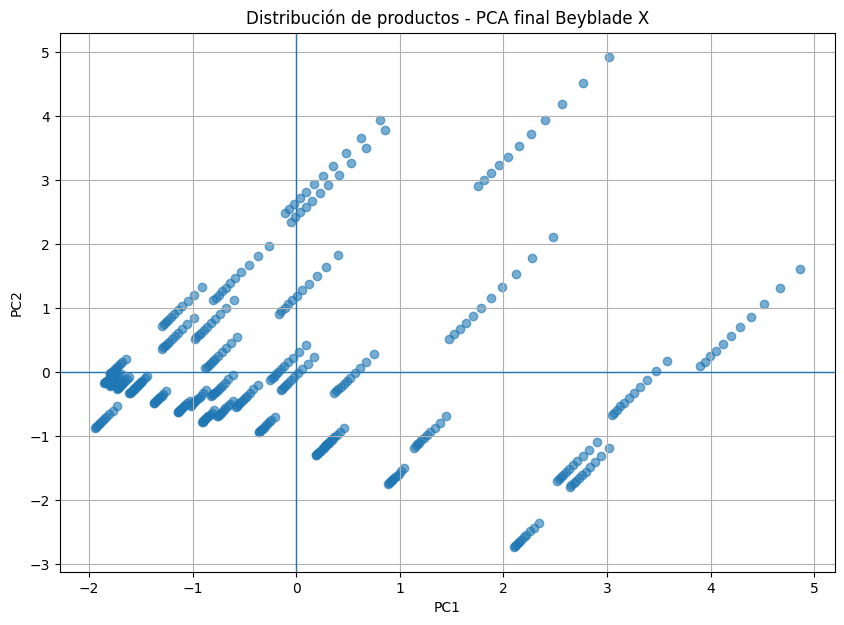

In [52]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df_resultado_pca["PC1"],
    df_resultado_pca["PC2"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Distribución de productos - PCA final Beyblade X"
)

plt.grid()

plt.show()

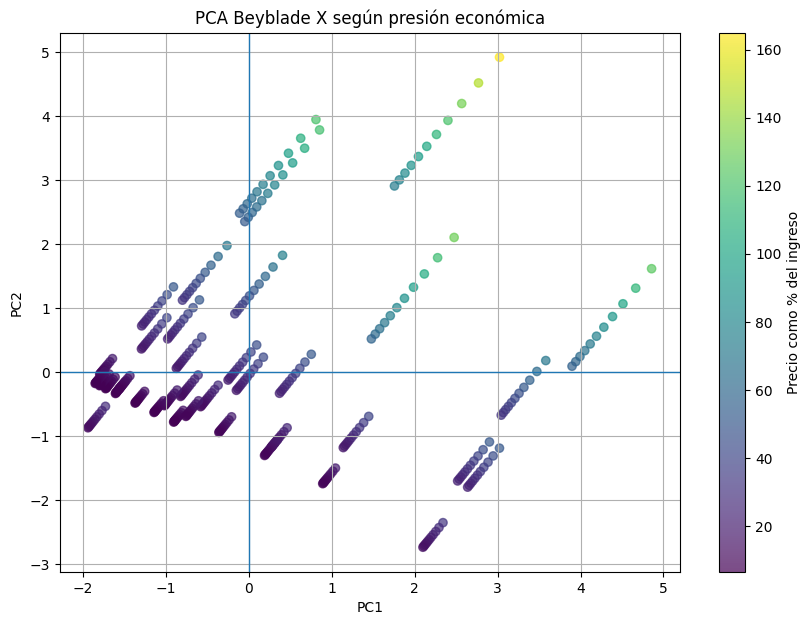

In [53]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_resultado_pca["PC1"],
    df_resultado_pca["PC2"],
    c=df_resultado_pca["price_income_pct"],
    alpha=0.7
)

plt.colorbar(
    scatter,
    label="Precio como % del ingreso"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "PCA Beyblade X según presión económica"
)

plt.grid()

plt.show()

In [54]:
print(
    dataset["product_name"]
    .drop_duplicates()
    .tolist()
)

['BX-00 Beyblade 25th Anniversary Set', 'BX-00 Booster Cobalt Drake 4-60F Clear Ver.', 'BX-00 Booster Cobalt Drake 4-60F Metal Coat: Blue Ver.', 'BX-00 Booster Draciel Shield 7-60D', 'BX-00 Booster Dragoon Storm 4-60RA', 'BX-00 Booster Dran Sword 3-60F Version 2.0', 'BX-00 Booster Dranzer Spiral 3-80T', 'BX-00 Booster Dranzer Spiral 3-80T Black Ver.', 'BX-00 Booster Drigger Slash 4-80P', 'BX-00 Booster Hells Chain 5-60HT Metal Coat: Black', "BX-00 Booster Hell's Scythe 4-60T Metal Coat: Gold", 'BX-00 Booster Leon Claw 5-60P Metal Coat: Gold', 'BX-00 Booster Mammoth Task Metal Coat: Black', 'BX-00 Booster Rock Leone 6-80GN', 'BX-00 Booster Shark Edge 5-60GF Metal Coat: Blue', 'BX-00 Starter Cobalt Dragoon 9-60F Metal Coat: White J.League Ver.', 'BX-00 CoroCoro Croc Crunch 2-60Q Metal Coat: Green', 'BX-00 CoroCoro Hells Scythe 3-80F 3 in 1', 'BX-00 CoroCoro Phoenix Wing 9-80DB Metal Coat: Navy', 'BX-00 CoroCoro Starter Cobalt Dragoon 2-60C Metal Coat: Black', 'BX-00 Starter Dran Sword 1-

In [55]:
producto_ejemplo = "BX-00 Booster Dran Sword 3-60F Version 2.0"

In [56]:
trayectoria = df_resultado_pca[
    df_resultado_pca["product_name"]
    == producto_ejemplo
].copy()

trayectoria = trayectoria.sort_values(
    "ingreso_personal_mensual_mxn"
)

display(
    trayectoria[
        [
            "product_name",
            "ingreso_personal_mensual_mxn",
            "price",
            "price_income_pct",
            "PC1",
            "PC2"
        ]
    ]
)

,product_name,ingreso_personal_mensual_mxn,price,price_income_pct,PC1,PC2
55,BX-00 Booster Dran Sword 3-60F Version 2.0,4001,999.0,24.968758,0.460153,-0.865550
56,BX-00 Booster Dran Sword 3-60F Version 2.0,4500,999.0,22.200000,0.421845,-0.926356
57,BX-00 Booster Dran Sword 3-60F Version 2.0,5000,999.0,19.980000,0.391129,-0.975110
58,BX-00 Booster Dran Sword 3-60F Version 2.0,5500,999.0,18.163636,0.365997,-1.014999
59,BX-00 Booster Dran Sword 3-60F Version 2.0,6000,999.0,16.650000,0.345055,-1.048241
60,BX-00 Booster Dran Sword 3-60F Version 2.0,6500,999.0,15.369231,0.327334,-1.076368
61,BX-00 Booster Dran Sword 3-60F Version 2.0,7000,999.0,14.271429,0.312144,-1.100477
62,BX-00 Booster Dran Sword 3-60F Version 2.0,7500,999.0,13.320000,0.298980,-1.121372
63,BX-00 Booster Dran Sword 3-60F Version 2.0,8000,999.0,12.487500,0.287462,-1.139654
64,BX-00 Booster Dran Sword 3-60F Version 2.0,8500,999.0,11.752941,0.277299,-1.155786


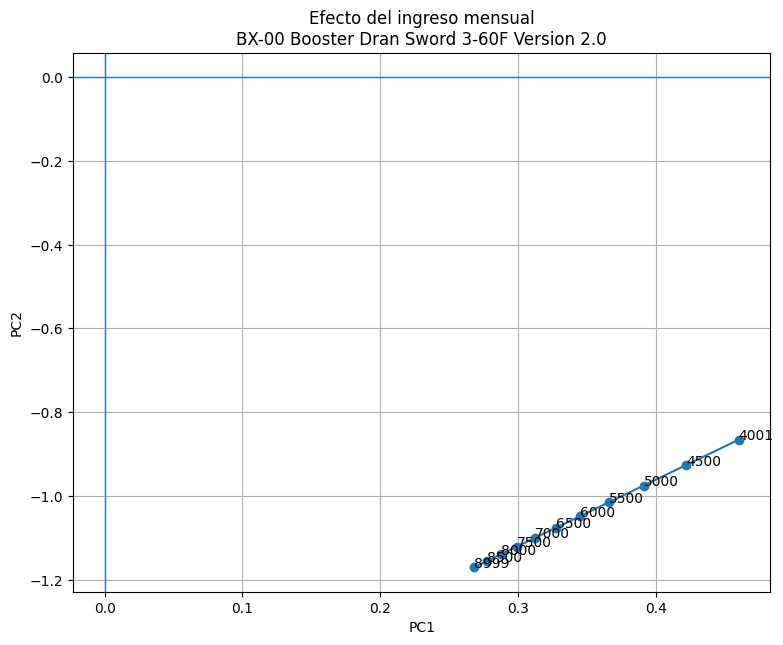

In [57]:
plt.figure(figsize=(9, 7))

plt.plot(
    trayectoria["PC1"],
    trayectoria["PC2"],
    marker="o"
)

for _, fila in trayectoria.iterrows():

    plt.annotate(
        int(
            fila[
                "ingreso_personal_mensual_mxn"
            ]
        ),
        (
            fila["PC1"],
            fila["PC2"]
        )
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    f"Efecto del ingreso mensual\n{producto_ejemplo}"
)

plt.grid()

plt.show()